In [8]:
from sklearn.model_selection import cross_val_score
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
# Example of finding the best K

In [9]:
data = pd.read_csv('/Users/garimau/dev/dsdp-ucsf/UCSFDelirium/AdmissionGenes/admission.csv')
data.head()
X = data.drop(columns=['Diagnosis'], inplace=False)
y = data['Diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
accuracies = []
for k in range(3, 15):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    accuracies.append(scores.mean())
optimal_k = accuracies.index(max(accuracies)) + 3
#print(len(accuracies))
print("Optimal K:", optimal_k)

Optimal K: 12


In [11]:
knn = KNeighborsClassifier(n_neighbors=optimal_k, weights = 'distance', metric='manhattan')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
#print(y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)
#using all of the features the 0.6153846153846154

0.782608695652174


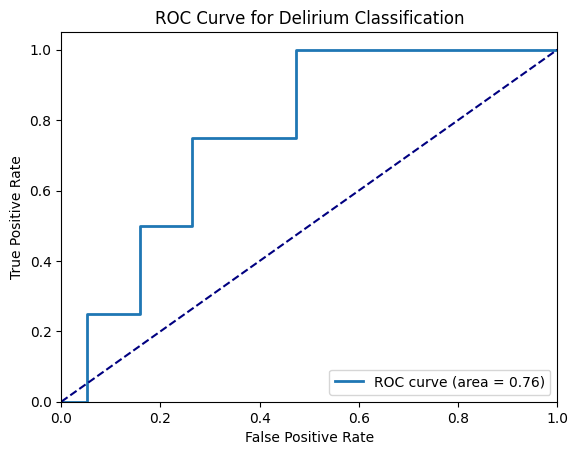

In [12]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_probs = knn.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Delirium Classification')
plt.legend(loc="lower right")
plt.show()

In [6]:
# Create SHAP KernelExplainer for Logistic Regression
import shap
import matplotlib.pyplot as plt

explainer = shap.KernelExplainer(lambda x: knn.predict_proba(x)[:, 1], X_train)  # Focus on the positive class (1)
shap_values = explainer.shap_values(X_train)
# Detailed SHAP summary plot
shap.summary_plot(shap_values, X_train, show=False)
plt.title("Logistic Regression SHAP Summary Plot")
plt.show()

/Users/garimau/dev/dsdp-ucsf/UCSFDelirium/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/garimau/dev/dsdp-ucsf/UCSFDelirium/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
  0%|          | 0/89 [00:00<?, ?it/s]

: 

In [7]:
feature_selection = X[['Age at Admission', 'SOFA', 'WHO Scale']]
X_trainFS, X_testFS, y_trainFS, y_testFS = train_test_split(feature_selection, y, test_size=0.2, random_state=42)

KeyError: "None of [Index(['Age at Admission', 'SOFA', 'WHO Scale'], dtype='object')] are in the [columns]"

In [ ]:
accuraciesFS = []
for k in range(3, 15):
    knnFS = KNeighborsClassifier(n_neighbors=k)
    scoresFS = cross_val_score(knnFS, X_trainFS, y_trainFS, cv=5, scoring='accuracy')
    accuraciesFS.append(scores.mean())
optimal_kFS = accuraciesFS.index(max(accuraciesFS)) + 3
#print(len(accuracies))
print("Optimal K:", optimal_kFS)

Optimal K: 3


In [ ]:
knn_FS = KNeighborsClassifier(n_neighbors=optimal_kFS, weights = 'distance', metric='manhattan')
knn_FS.fit(X_trainFS, y_trainFS)
y_predFS = knn_FS.predict(X_testFS)
#print(y_pred)
accuracyFS = accuracy_score(y_testFS, y_predFS)
print(accuracyFS)
#using all of the features the 0.6153846153846154


0.5769230769230769


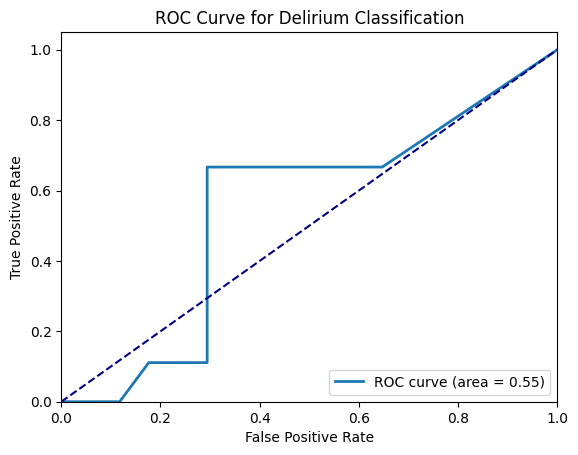

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_probsFS = knn_FS.predict_proba(X_testFS)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_testFS, y_probsFS)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Delirium Classification')
plt.legend(loc="lower right")
plt.show()

/Users/garimau/dev/dsdp-ucsf/UCSFDelirium/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
Using 102 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
  0%|          | 0/102 [00:00<?, ?it/s]/Users/garimau/dev/dsdp-ucsf/UCSFDelirium/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/Users/garimau/dev/dsdp-ucsf/UCSFDelirium/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/Users/garimau/dev/dsdp-ucsf/UCSFDelirium/.venv/lib/python3.13/site-packages/sklearn/utils/valid

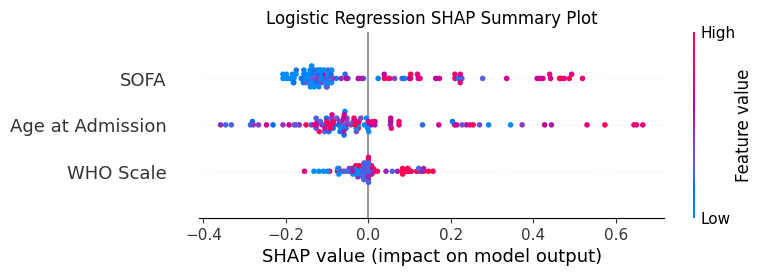

In [17]:
import shap
import matplotlib.pyplot as plt

explainerFS = shap.KernelExplainer(lambda x: knn_FS.predict_proba(x)[:, 1], X_trainFS)  # Focus on the positive class (1)
shap_valuesFS = explainerFS.shap_values(X_trainFS)
# Detailed SHAP summary plot
shap.summary_plot(shap_valuesFS, X_trainFS, show=False)
plt.title("Logistic Regression SHAP Summary Plot")
plt.show()